# Lesson 191 · Published-table reconstruction

<p class="eyebrow">Year 5 · Q4 · Lesson 191 · Read the comparison contract</p>

# What does “ahead of the best open model” mean?

[Lesson 190](https://avistian.github.io/relational/lessons/0190-research-gap-checkpoint.html) turned saved evidence into a research question. Before choosing the baseline for that question, you need a trustworthy performance comparison. A large headline advantage can shrink when you change the eligible methods, the task coverage or the arithmetic.

**Your win:** build a dated, auditable KumoRFM-2 versus open-method gap table and defend exactly what it means. Read the core in about 15 minutes; use the notebook for implementation and the expandable tables for audit detail. This supports our mission: make a relational-learning research claim that a skeptical reader can check.

<div class="sota-status"><strong>Complete selected-table reconstruction.</strong> 401 task scores · 45 method rows · $0 cloud/API. Fresh inference: NOT_RUN. Historical model reproduction and current global SOTA: NOT_ESTABLISHED. Learner defense: pending.</div>

## 1 · Retrieve before reading

Without looking back, explain: (1) why replaying a score is different from fresh inference; (2) why choosing a model on test results is unsuitable for deployment; (3) why MAEs from different tasks cannot simply be averaged. Recall [L165](https://avistian.github.io/relational/lessons/0165-kumorfm-in-context-relational-learning.html) and the [research-gap checkpoint](https://avistian.github.io/relational/lessons/0190-research-gap-checkpoint.html).


<p>Write your three answers above, then check them against the reference card.</p>

## 2 · Model architecture: where the task enters

> **In plain terms.** The model first learns which cells matter for this task. It then combines related rows and labeled examples to predict a query row.

**Context** means examples whose targets are already known at the relevant cutoff. The **query** is the example whose target we want. A foreign key connects a row to a row in another table. The query label stays hidden; known context labels enter early, so feature extraction can depend on the task.

The paper describes a small table-level network alternating attention across columns and rows. A larger network mixes row representations along foreign-key links and across context examples. The four axes are directions of information exchange, not four mandatory loss terms. The final representation predicts the query target. [Primary reading: §3 and Figure 3](https://arxiv.org/html/2604.12596v1#S3).

<figure class="sota-figure sota-architecture">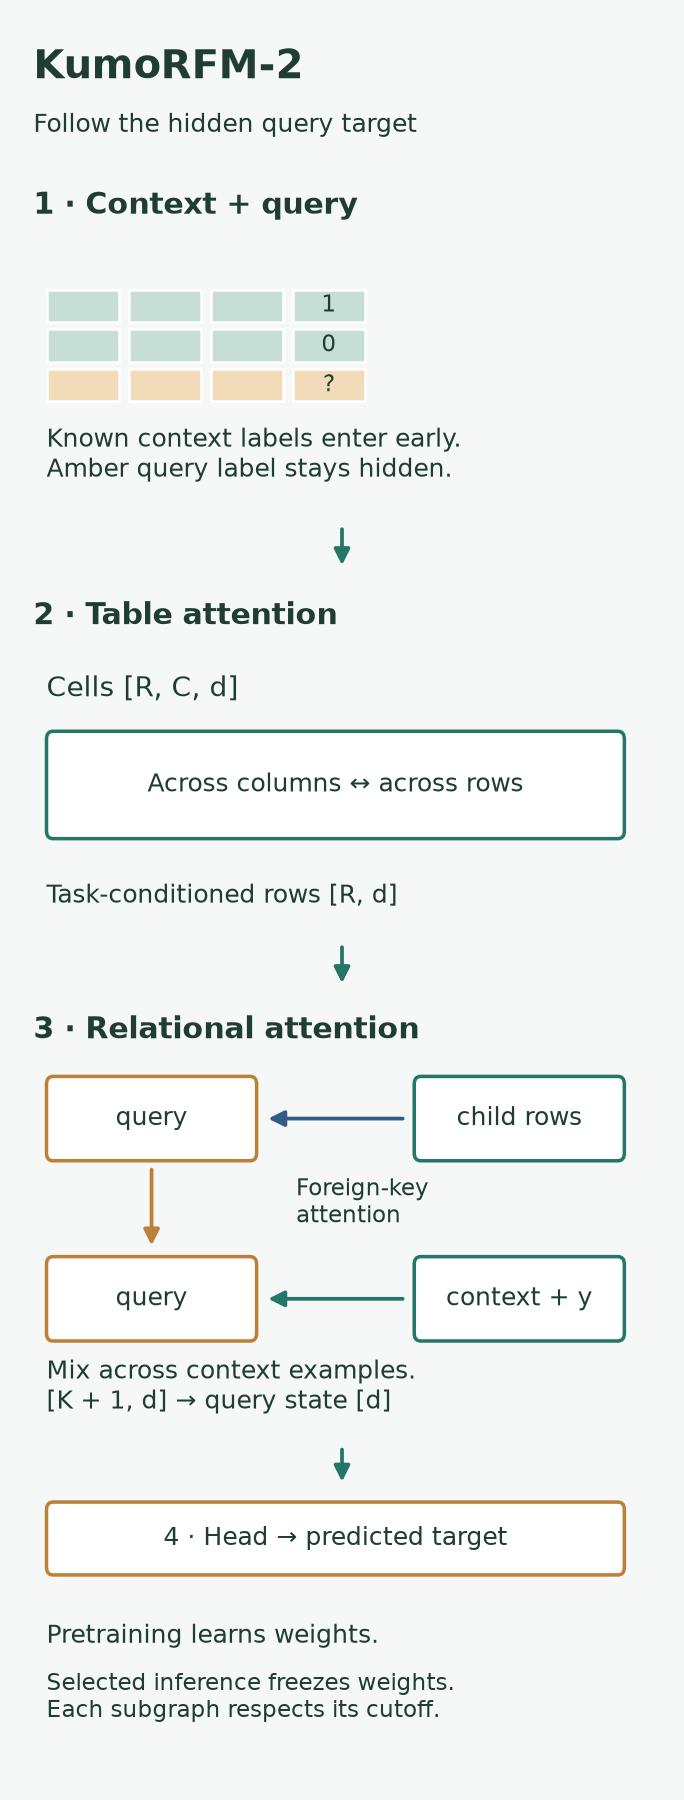<figcaption>Conceptual KumoRFM-2 forward path from §3. Amber tracks the query; known context labels enter the table stage. Symbolic dimensions and illustrative rows, not recovered weights or an executed model.</figcaption></figure>

**Trace the highlighted query:** its cells become a row vector; connected child rows contribute information; labeled context examples inform the prediction. Each context subgraph respects its example's time cutoff. The paper also describes local/history and recent global context, lagged targets, and ensembling. These are protocol choices to audit, not details to replace with convenient defaults.

Pretraining learns weights across synthetic and real tasks. In the selected paper tables, in-context inference uses frozen base-model weights and at most 10,000 context examples, drawing from training and validation splits. Fine-tuning is a separate experiment. The schematic uses symbolic dimensions: *R* rows, *C* columns, *d* embedding width and *K* context examples. It does not invent unreleased widths, layer counts, weights or a trainer. [§§3–4](https://arxiv.org/html/2604.12596v1#S4).

**Predict:** if the desired target changes from churn to future spending, which stage should first be able to use that task information? Explain why simply concatenating a task label at the final head would depict a different mechanism.

## 3 · Freeze the question before computing the gap

A **comparison contract** records source version, tasks, metric, eligible methods and aggregation. Our frozen source is **KumoRFM-2 v1, 14 April 2026, Tables 3, 4, 7 and 8**. It contains 28 task columns across four suites of results. Every one of its 401 task cells and 90 summary cells is preserved and independently parsed.

“Open” here means **an inspected open implementation**. It does not certify every backend's weight license, the original training corpus or historical reproducibility. The bounded foundation pool is RDBLearn and Griffin. The bounded supervised pool is LightGBM, GraphSAGE, RelGNN and RelGT. Other published rows remain in the complete source tables but are outside this access audit. OpenRFM is a later paper and has no row in this frozen comparison.

All included values are **paper-reported test results**; we did not independently establish equal information access across the authors' runs. The paper permits training-plus-validation context for Kumo. Treat the resulting gap as descriptive published evidence, not as a controlled architecture ablation.

**Two different questions:**

- **Single method:** which eligible method has the best aggregate across all tasks in this table? This is a retrospective test-set summary; a deployable choice needs validation data.
- **Taskwise oracle:** what if we picked the best eligible test result separately for every task? This is an optimistic envelope, not one trained model or a valid selection policy.

Require complete coverage. A missing task is not a zero or a loss. Do not let a method evaluated on one easy task compete against an all-task average.

## 4 · Work one calculation, then change the pool

**Worked example — driver-dnf.** The displayed AUROCs are 84.59 for KumoRFM-2 and 70.87 for RDBLearn. The difference is **13.72 percentage points**, or 0.1372 on a 0–1 AUROC scale. It is not a 13.72% relative improvement.

For a regression task, smaller MAE is better. On ratebeer/user-count, 7.298 versus 7.374 means **0.076 raw MAE units in Kumo's favor**. These units belong to that task. To combine regression tasks, first divide each method's MAE by the same task's LightGBM MAE, then average those ratios. The LightGBM reference is therefore exactly 1.

$$\text{gap}_{AUC}=AUC_{Kumo}-AUC_{open},\qquad \text{gap}_{MAE}=MAE_{open}-MAE_{Kumo}.$$

$$\mu_m=\frac{1}{T}\sum_{t=1}^{T}\frac{MAE_{m,t}}{MAE_{LightGBM,t}}.$$

Here *T* is the number of tasks, *t* indexes a task, and *m* names a method. A positive gap means Kumo is better. For regression aggregates we subtract normalized means; that result is dimensionless, not a percentage or a raw MAE.

**Predict before revealing:** will the “best open” gap grow or shrink if supervised methods become eligible?


<p>It shrinks on Table 3: the bounded supervised pool includes RelGNN, which is stronger on the aggregate than RDBLearn.</p>

<figure class="sota-figure">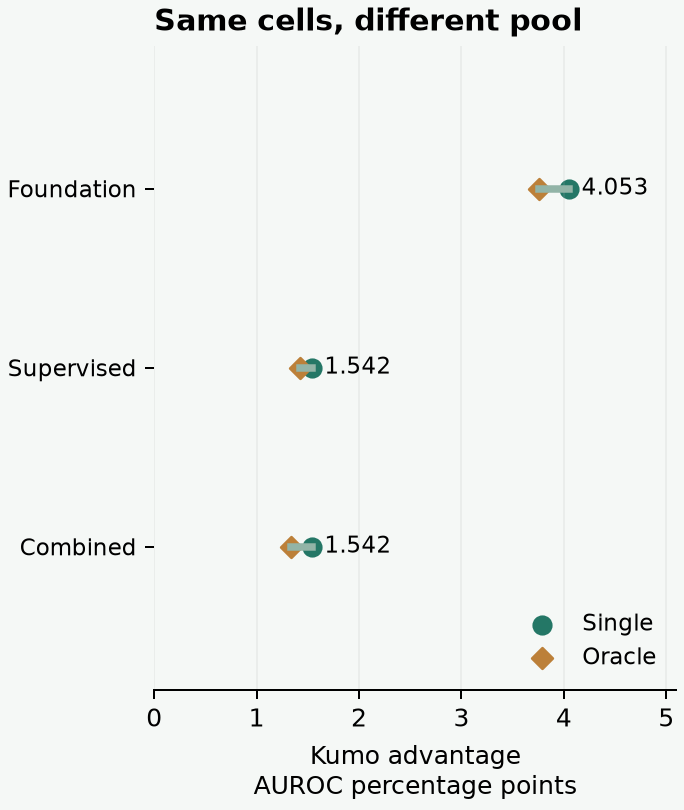<figcaption>Computed from all 12 Table 3 task columns. The single-method gap is 4.053 AUROC points for the bounded foundation pool and 1.542 for the supervised pool. Oracle selection is descriptive and uses test outcomes.</figcaption></figure>

| Table | Bounded open pool | Best single method | Kumo advantage | Unit |
|---|---|---|---|---|
| 3 | foundation | RDBLearn | 4.053333 | AUROC points |
| 3 | supervised | RelGNN | 1.541667 | AUROC points |
| 4 | foundation | No eligible row | Missing | AUROC points |
| 4 | supervised | GraphSAGE | 1.590000 | AUROC points |
| 7 | foundation | RDBLearn | 0.083535 | normalized MAE |
| 7 | supervised | RelGNN | 0.039161 | normalized MAE |
| 8 | foundation | No eligible row | Missing | normalized MAE |
| 8 | supervised | GraphSAGE | 0.024398 | normalized MAE |


**Try it:** change the pool, then the selection rule. Keep the source fixed. Explain why a different gap need not imply that any model changed.


<p>The static summary above and full tables below preserve every result. The notebook lets you change the same comparison assumptions in Python.</p>

The TODO cells below implement direction, eligibility and full-coverage comparison.

## 5 · Audit the arithmetic before repeating the headline

Our independent parser and rational-arithmetic check found **five aggregates outside displayed-rounding bounds**. For example, the five Table 4 KumoRFM-2 cells average to **79.782**, while the paper prints **79.96**. A printed value with two decimals represents approximately ±0.005 rounding uncertainty. Even allowing that uncertainty in both task cells and summary cannot bridge this difference.

| Table | Method | Published | From cells | Cell-rounding bounds |
|---|---|---|---|---|
| 3 | RT_zero | 67.730000 | 70.649167 | 70.644167–70.654167 |
| 3 | RDBLearn | 75.970000 | 75.547500 | 75.542500–75.552500 |
| 4 | KumoRFM-1 | 76.220000 | 76.098000 | 76.093000–76.103000 |
| 4 | KumoRFM-2 | 79.960000 | 79.782000 | 79.777000–79.787000 |
| 8 | KumoRFM-1 | 0.712000 | 0.720692 | 0.719851–0.721534 |


This is a reproducible discrepancy under the stated arithmetic. It does not identify its cause. Different unpublished inputs, aggregation choices or a transcription problem would require author clarification. We preserve the published number alongside the recomputed one.

**Ranks need a contract too.** Rank 1 means best within a specified method pool. Our ranks include all displayed rows in that table and assign tied displayed scores their average occupied rank. Two tied leaders therefore receive 1.5 each. **34 of 45** printed mean ranks differ from this rule. Hidden precision can break displayed ties; a different rank pool can also change ranks. Those causes are not established here. Rank differences are reported as `DIFFERS_DISPLAYED`, not automatically as paper errors.

> **Scope check.** Rounding intervals are bounds from printed precision, not statistical confidence intervals. The tables do not give us per-seed predictions. Do not invent error bars, a significance test or a fresh-run uncertainty estimate.

### Table 3 · RelBenchV1 · AUROC

| Method | f1/dnf | f1/top3 | avito/click | avito/visit | event/repeat | event/ignore | trial/out | amazon/user | amazon/item | stack/eng | stack/badge | hm/churn | Published avg | Recomputed avg | Published rank | Displayed rank |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| LightGBM | 68.56 | 73.92 | 53.60 | 53.05 | 68.04 | 79.93 | 70.09 | 52.22 | 62.54 | 63.39 | 63.43 | 55.21 | 63.67 | 63.665000 | 16.75 | 15.750000 |
| DS+LightGBM | 69.80 | 82.40 | 64.27 | 64.46 | 75.42 | 84.23 | 72.00 | 67.60 | 81.80 | 90.30 | 86.20 | 69.00 | 75.62 | 75.623333 | 7.75 | 6.916667 |
| DS+AutoGluon * | 70.01 | 82.53 | 65.66 | 65.87 | 74.85 | 82.31 | 70.51 | 68.12 | 80.45 | 89.94 | 85.38 | 68.71 | 75.36 | 75.361667 | 8.5 | 7.500000 |
| DS+TabPFN-2.5 * | 71.16 | 77.70 | 64.21 | 64.53 | 76.43 | 85.70 | 70.75 | 66.28 | 79.83 | 89.07 | 85.08 | 68.31 | 74.92 | 74.920833 | 9.5 | 8.416667 |
| GraphSAGE | 72.62 | 75.54 | 65.90 | 66.20 | 76.89 | 81.62 | 68.60 | 70.42 | 82.81 | 90.59 | 88.86 | 69.88 | 75.83 | 75.827500 | 6.42 | 5.416667 |
| HGT | 70.77 | 70.75 | 63.76 | 64.32 | 64.96 | 82.47 | 58.37 | 66.43 | 77.97 | 88.47 | 86.08 | 66.95 | 71.78 | 71.775000 | 12.5 | 11.500000 |
| HGT_PE | 71.17 | 76.27 | 64.57 | 64.95 | 65.36 | 81.61 | 59.21 | 66.19 | 78.03 | 88.17 | 85.66 | 65.69 | 72.24 | 72.240000 | 11.75 | 10.750000 |
| RelGNN | 75.29 | 85.69 | 68.23 | 66.18 | 79.61 | 86.18 | 71.24 | 70.99 | 82.64 | 90.75 | 88.98 | 70.93 | 78.06 | 78.059167 | 3.75 | 3.000000 |
| RelGT | 75.87 | 83.52 | 68.30 | 66.78 | 76.09 | 81.57 | 68.61 | 70.39 | 82.55 | 90.53 | 86.32 | 69.27 | 76.65 | 76.650000 | 6.0 | 5.041667 |
| LLM1 | 75.80 | 91.40 | 59.80 | 62.70 | 71.40 | 69.30 | 57.40 | 58.10 | 62.10 | 78.00 | 80.00 | 59.80 | 68.82 | 68.816667 | 13.92 | 12.958333 |
| LLM2 | 80.03 | 87.11 | 53.36 | 54.07 | 70.11 | 68.65 | 59.17 | 62.55 | 73.41 | 81.23 | 79.99 | 63.81 | 69.46 | 69.457500 | 13.92 | 12.916667 |
| TabPFN-2.5 * | 61.21 | 77.35 | 54.44 | 51.45 | 69.10 | 70.91 | 71.74 | 57.14 | 59.30 | 59.66 | 52.26 | 54.99 | 61.63 | 61.629167 | 16.42 | 15.500000 |
| Griffin | 57.70 | 82.50 | 45.90 | 60.70 | 71.88 | 83.27 | 51.00 | 62.30 | 69.00 | 77.50 | 73.50 | 60.20 | 66.29 | 66.287500 | 15.42 | 14.416667 |
| RT_zero | 81.20 | 89.30 | 59.50 | 61.80 | 73.22 | 77.47 | 51.80 | 64.00 | 70.90 | 75.70 | 80.10 | 62.80 | 67.73 | 70.649167 | 13.25 | 12.250000 |
| GNN+TabPFN | 64.26 | 74.67 | 60.68 | 65.35 | 73.58 | 84.13 | 56.68 | 64.30 | 77.89 | 87.48 | 85.34 | 64.34 | 71.56 | 71.558333 | 12.58 | 11.583333 |
| RDBLearn | 70.87 | 79.69 | 69.04 | 65.49 | 75.04 | 82.52 | 71.58 | 67.57 | 82.07 | 89.39 | 85.26 | 68.05 | 75.97 | 75.547500 | 8.08 | 7.166667 |
| KumoRFM-1 | 82.41 | 91.07 | 64.85 | 64.11 | 76.08 | 89.20 | 70.79 | 67.29 | 79.93 | 87.09 | 80.00 | 67.71 | 76.71 | 76.710833 | 8.33 | 7.375000 |
| KumoRFM-2 | 84.59 | 92.18 | 67.42 | 69.41 | 81.66 | 90.83 | 72.03 | 69.10 | 82.17 | 89.40 | 87.15 | 69.27 | 79.6 | 79.600833 | 3.08 | 2.541667 |



### Table 4 · RelBenchV2 · AUROC

| Method | mimic/stay | ratebeer/beer-churn | ratebeer/user-churn | ratebeer/dormant | arxiv/citation | Published avg | Recomputed avg | Published rank | Displayed rank |
|---|---|---|---|---|---|---|---|---|---|
| LightGBM | 51.81 | 76.21 | 83.92 | 75.79 | 71.21 | 71.79 | 71.788000 | 3.8 | 3.800000 |
| GraphSAGE | 55.01 | 78.67 | 94.27 | 80.51 | 82.50 | 78.19 | 78.192000 | 2.0 | 2.000000 |
| KumoRFM-1 | 56.33 | 75.06 | 91.38 | 77.10 | 80.62 | 76.22 | 76.098000 | 2.8 | 2.800000 |
| KumoRFM-2 | 55.28 | 83.84 | 97.43 | 80.65 | 81.71 | 79.96 | 79.782000 | 1.75 | 1.400000 |



### Table 7 · RelBenchV1 · MAE

| Method | f1/pos | avito/ctr | event/attend | trial/adverse | trial/success | amazon/user | amazon/item | stack/votes | hm/sales | Published avg | Recomputed avg | Published rank | Displayed rank |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Global Median | 4.399 | 0.043 | 0.264 | 57.533 | 0.462 | 16.783 | 64.234 | 0.068 | 0.076 | 1.062 | 1.062056 | 12.78 | 12.222222 |
| Entity Median | 8.519 | 0.046 | 0.269 | 57.930 | 0.441 | 17.423 | 66.436 | 0.069 | 0.078 | 1.19 | 1.190416 | 14.0 | 14.055556 |
| LightGBM | 4.170 | 0.041 | 0.264 | 44.011 | 0.425 | 16.783 | 60.569 | 0.068 | 0.076 | 1.0 | 1.000000 | 10.22 | 9.611111 |
| DS+LightGBM | 3.963 | 0.044 | 0.284 | 40.581 | 0.407 | 13.928 | 41.122 | 0.065 | 0.036 | 0.879 | 0.879709 | 5.11 | 4.888889 |
| DS+AutoGluon * | 4.251 | 0.045 | 0.256 | 44.706 | 0.430 | 14.399 | 45.390 | 0.068 | 0.043 | 0.918 | 0.920819 | 7.11 | 7.388889 |
| DS+TabPFN-2.5 * | 4.373 | 0.044 | 0.318 | 47.168 | 0.432 | 15.631 | 47.908 | 0.080 | 0.059 | 1.009 | 1.009968 | 10.11 | 10.111111 |
| GraphSAGE | 4.022 | 0.041 | 0.258 | 44.473 | 0.400 | 14.313 | 50.053 | 0.065 | 0.056 | 0.918 | 0.918376 | 6.33 | 6.166667 |
| HGT | 4.226 | 0.046 | 0.264 | 45.169 | 0.443 | 15.412 | 55.868 | 0.068 | 0.064 | 0.988 | 0.987427 | 10.44 | 10.611111 |
| HGT_PE | 4.392 | 0.048 | 0.261 | 42.648 | 0.440 | 15.864 | 55.849 | 0.068 | 0.064 | 0.992 | 0.991817 | 10.0 | 9.833333 |
| RelGNN | 3.798 | 0.037 | 0.238 | 44.461 | 0.301 | 14.230 | 48.767 | 0.065 | 0.054 | 0.861 | 0.861405 | 4.44 | 4.277778 |
| RelGT | 3.917 | 0.035 | 0.250 | 43.992 | 0.326 | 14.267 | 48.922 | 0.065 | 0.054 | 0.869 | 0.870087 | 4.67 | 4.555556 |
| TabPFN-2.5 * | 4.446 | 0.044 | 0.527 | 55.187 | 0.469 | 17.513 | 60.996 | 0.104 | 0.096 | 1.258 | 1.259572 | 14.78 | 14.777778 |
| Griffin | 4.460 | 0.050 | 0.461 | 78.232 | 0.463 | 35.590 | 53.214 | 0.092 | 0.151 | 1.471 | 1.471243 | 15.44 | 15.444444 |
| RT_zero | 2.901 | 0.058 | 0.379 | 73.999 | 0.455 | 18.802 | 57.996 | 0.110 | 0.089 | 1.24 | 1.240490 | 14.0 | 14.000000 |
| RDBLearn | 3.834 | 0.034 | 0.237 | 43.913 | 0.424 | 14.540 | 48.559 | 0.068 | 0.064 | 0.906 | 0.905779 | 5.89 | 5.555556 |
| KumoRFM-1 | 2.747 | 0.035 | 0.264 | 58.231 | 0.417 | 16.161 | 55.254 | 0.065 | 0.040 | 0.908 | 0.908231 | 7.22 | 6.888889 |
| KumoRFM-2 | 2.854 | 0.034 | 0.235 | 43.293 | 0.433 | 13.921 | 46.992 | 0.064 | 0.034 | 0.822 | 0.822244 | 2.67 | 2.611111 |



### Table 8 · RelBenchV2 · MAE

| Method | ratebeer/user-count | arxiv/publication | Published avg | Recomputed avg | Published rank | Displayed rank |
|---|---|---|---|---|---|---|
| Global Median | 15.124 | 0.577 | 0.872 | 0.871597 | 4.5 | 4.750000 |
| Entity Median | 13.079 | 0.874 | 1.079 | 1.078717 | 5.0 | 5.000000 |
| LightGBM | 20.350 | 0.577 | 1.0 | 1.000000 | 5.0 | 5.250000 |
| GraphSAGE | 7.374 | 0.513 | 0.626 | 0.625720 | 2.0 | 2.000000 |
| KumoRFM-1 | 11.063 | 0.518 | 0.712 | 0.720692 | 3.0 | 3.000000 |
| KumoRFM-2 | 7.298 | 0.487 | 0.601 | 0.601322 | 1.0 | 1.000000 |



* marks a baseline evaluated by the Kumo authors. Other baseline values were taken from cited work. Source table ranks use an unestablished pool/precision convention; recomputed ranks use every displayed row.

## 6 · Keep the date visible

A frozen paper comparison answers “what does this source report?” It cannot certify today's global SOTA. Our bounded **2 October 2026** source check found a June OpenRFM paper and a July RDBLearn v1.1 paper. These need separate protocol review before their results can enter a comparable pool. The April tables stay immutable. [OpenRFM v1](https://arxiv.org/html/2606.04320v1) · [RDBLearn update v1](https://arxiv.org/html/2607.05476v1).

The source-access attempt also encountered HTTP 404 for the Kumo repository and HTTP 401 for a leaderboard data endpoint. Those are retrieval failures, not proof that the resources do not exist. Keep the failed attempts, leave **current global SOTA `NOT_ESTABLISHED`**, and state the actual search boundary. [Frozen tracking ledger](https://avistian.github.io/relational/labs/evidence/l191/packet/tracking-ledger.json).

For [Lesson 192's open-model reproduction](https://avistian.github.io/relational/lessons/0192-open-fm-setup-data.html), use this table to shortlist a baseline. Then audit weights, data identity, temporal rules, feature construction, context/seed choices, validation-only selection and aggregate cost before execution. An inspected repository alone does not finish that contract.

## 7 · Build it and defend it

[Student notebook](https://avistian.github.io/relational/labs/0191-kumorfm2-sota-tracking.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/solutions/0191-kumorfm2-sota-tracking.ipynb) · [Read the executed lab](https://avistian.github.io/relational/labs/html/0191-kumorfm2-sota-tracking.html) · [Reference card](https://avistian.github.io/relational/reference/kumorfm2-sota-tracking.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l191-reproduction.md).

The notebook embeds the frozen source packet and the full parser/reconstruction implementation. Three learner functions control metric direction, evidence eligibility and complete-coverage comparison. Its checks feed those functions into the real 401-cell reconstruction. It uses Python's standard library; no model, API key or repository checkout is needed.

**EXIT:** submit one gap with its table, pool, rule, units and source date. Explain one published/recomputed discrepancy, one missing comparison and one condition that would make a fresh run comparable. State how your baseline choice changes the research question from L190.


<p>Explain why “4.05 points ahead” cannot by itself establish current global superiority or a successful fresh reproduction. Include the pool and the evidence date.</p>

Ask the teaching agent about any unclear calculation or bring your written defense for feedback. Tomorrow, reconstruct the direction of both gap formulas from memory. In one week, defend the difference between one method and a taskwise oracle without reopening the table.


## PROVIDED · Offline bootstrap
Python 3.10+ standard library only. No installs, API calls, GPU or model inference. The embedded packet contains original HTML, access receipts, the complete extracted tables and policy. Source archive integrity is checked before extraction. Online course links are optional reading, not execution dependencies.

In [1]:
import base64, hashlib, io, json, math, re, tempfile, zipfile
from html.parser import HTMLParser
from pathlib import Path
workspace=Path(tempfile.mkdtemp(prefix="l191-replay-"))

In [2]:
payload='...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='962961c7d76d956202e70a2398f22b9d1f4c1eebe0dbead01324bd4af278eb80'
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():
        if not (workspace/name).resolve().is_relative_to(workspace.resolve()):
            raise ValueError("Unsafe archive path")
    z.extractall(workspace)
packet=workspace/"packet"
manifest=json.loads((workspace/"input-manifest.json").read_text())

## PROVIDED · Midranks
Equal displayed values share the mean of their occupied ranks. This helper does not recover unpublished precision.

In [3]:
def average_ranks(values, higher):
    """Midranks of displayed values; hidden precision cannot be recovered."""
    if not values or any(not math.isfinite(v) for v in values):
        raise ValueError('Require nonempty finite scores')
    return [1.0 + sum((w > v if higher else w < v) for w in values)
            + (sum(w == v for w in values) - 1) / 2 for v in values]

## TODO · signed_gap
Return a positive value when Kumo is better. Accept only AUROC and MAE; reject nonfinite numbers. AUROC inputs are in published percentage units.

Before coding, predict one input that must be rejected or excluded.

In [4]:
def signed_gap(target, comparator, metric):
    """Positive means Kumo is better; AUROC inputs use published percent units."""
    if metric not in ('AUROC', 'MAE') or not all(math.isfinite(x) for x in (target, comparator)):
        raise ValueError('Require finite values and AUROC or MAE')
    return target - comparator if metric == 'AUROC' else comparator - target

### CHECK · Synthetic edge cases

In [5]:
assert abs(signed_gap(84.59,70.87,'AUROC')-13.72)<1e-10
assert abs(signed_gap(7.298,7.374,'MAE')-.076)<1e-10
try: signed_gap(float('nan'),1,'MAE')
except ValueError: pass
else: raise AssertionError('Reject nonfinite values')
print("Contract examples PASS")

Contract examples PASS


## TODO · eligible
Require access=open_code and protocol=reported_same_table. Include only foundation/supervised families; pool is foundation, supervised or all. Missing evidence returns False. Unknown pool raises ValueError.

Before coding, predict one input that must be rejected or excluded.

In [6]:
def eligible(metadata, pool):
    """Eligibility is an audited policy, not a claim of full reproducibility."""
    if pool not in ('foundation', 'supervised', 'all'):
        raise ValueError('Unknown pool')
    return (metadata.get('access') == 'open_code'
            and metadata.get('protocol') == 'reported_same_table'
            and metadata.get('family') in ('foundation', 'supervised')
            and (pool == 'all' or metadata['family'] == pool))

### CHECK · Synthetic edge cases

In [7]:
m=dict(access='open_code',protocol='reported_same_table',family='foundation')
assert eligible(m,'foundation')
assert not eligible(dict(m,access='unverified'),'all')
assert not eligible(m,'supervised')
assert not eligible({},'all')
print("Contract examples PASS")

Contract examples PASS


## TODO · compare_pool
Implement a complete-coverage comparison. Reject wrong lengths and nonfinite values; exclude rows with None. Return NO_ELIGIBLE_COMPARATOR when none remain. Otherwise normalize MAE by positive per-task baseline, compute each mean, retain tied best single methods, form taskwise oracle and its tied methods, and return direction-correct gaps. Use the exact output contract below. All ties use absolute tolerance 1e-12 for aggregate scores; task ties use equality.

Before coding, predict one input that must be rejected or excluded.

Required successful fields: status=`COMPLETE_PUBLISHED_COMPARISON`; single_methods (sorted list), single_score, target_score, single_gap; oracle_values, oracle_methods (sorted list per task), oracle_score, oracle_gap; per_task_gaps (raw task units), excluded (sorted list). No-eligible output has only status and excluded. The single score is the strongest mean under the metric direction. Use your signed_gap function for every gap.

In [8]:
def compare_pool(target, candidates, metric, baseline=None):
    """Single method and descriptive taskwise oracle on complete common coverage.

    Selection uses published test scores: retrospective summary, not a deployment
    selection rule. For MAE aggregate ratios before averaging, never raw MAEs.
    """
    if not target or metric not in ('AUROC', 'MAE'):
        raise ValueError('Empty target or unknown metric')
    n = len(target)
    if any(not math.isfinite(v) for v in target):
        raise ValueError('Nonfinite target')
    if metric == 'MAE':
        if baseline is None or len(baseline) != n or any(not math.isfinite(v) or v <= 0 for v in baseline):
            raise ValueError('Require positive LightGBM baseline per task')
    scale = baseline if metric == 'MAE' else [1.0] * n
    complete, excluded = {}, []
    for name, values in candidates.items():
        if len(values) != n:
            raise ValueError('Task coverage length mismatch')
        if any(v is not None and not math.isfinite(v) for v in values):
            raise ValueError('Nonfinite candidate')
        if any(v is None for v in values):
            excluded.append(name)
        else:
            complete[name] = values
    if not complete:
        return dict(status='NO_ELIGIBLE_COMPARATOR', excluded=sorted(excluded))
    scores = {k: sum(v / b for v, b in zip(values, scale)) / n for k, values in complete.items()}
    choose = max if metric == 'AUROC' else min
    best = choose(scores.values())
    winners = sorted(k for k, v in scores.items() if math.isclose(v, best, rel_tol=0, abs_tol=1e-12))
    oracle = [choose(v[i] for v in complete.values()) for i in range(n)]
    oracle_methods = [sorted(k for k, v in complete.items() if v[i] == oracle[i]) for i in range(n)]
    target_score = sum(v / b for v, b in zip(target, scale)) / n
    oracle_score = sum(v / b for v, b in zip(oracle, scale)) / n
    return dict(status='COMPLETE_PUBLISHED_COMPARISON', single_methods=winners,
                single_score=best, target_score=target_score,
                single_gap=signed_gap(target_score, best, metric), oracle_values=oracle,
                oracle_methods=oracle_methods, oracle_score=oracle_score,
                oracle_gap=signed_gap(target_score, oracle_score, metric),
                per_task_gaps=[signed_gap(a, b, metric) for a, b in zip(target, oracle)],
                excluded=sorted(excluded))

### CHECK · Synthetic edge cases

In [9]:
x=compare_pool([8,6],{'a':[9,1],'b':[4,4],'partial':[10,None]},'AUROC')
assert x['single_methods']==['a'] and x['excluded']==['partial']
assert x['single_gap']==2 and x['oracle_gap']==.5
y=compare_pool([2,4],{'a':[4,4],'b':[2,8]},'MAE',[2,4])
assert y['single_methods']==['a','b'] and y['oracle_gap']==0
assert compare_pool([1],{},'AUROC')['status']=='NO_ELIGIBLE_COMPARATOR'
print("Contract examples PASS")

Contract examples PASS


## PROVIDED · Parse the original HTML
This parser visits only the four frozen table IDs, checks exact row counts and keeps printed decimals. It fails if the source shape changes. Database group headers are mapped explicitly to the paper task abbreviations.

In [10]:
def parse_tables(html):
    class Cells(HTMLParser):
        def __init__(self):
            super().__init__(); self.table=None; self.cell=None; self.row=[]; self.tables={}; self.annotation=False
        def handle_starttag(self,tag,attrs):
            a=dict(attrs)
            if tag=='figure' and a.get('id') in ('S4.T3','S4.T4','S4.T7','S4.T8'):
                self.table=a['id']; self.tables[self.table]=[]
            if self.table and tag=='tr':self.row=[]
            if self.table and tag in ('td','th'):self.cell=[]
            if tag=='annotation':self.annotation=True
        def handle_data(self,data):
            if self.cell is not None and not self.annotation:self.cell.append(data)
        def handle_endtag(self,tag):
            if tag=='annotation':self.annotation=False
            if self.table and tag in ('td','th') and self.cell is not None:
                self.row.append(' '.join(''.join(self.cell).split())); self.cell=None
            if self.table and tag=='tr':self.tables[self.table].append(self.row)
            if tag=='figure':self.table=None
    parser=Cells();parser.feed(html)
    config={3:('RelBenchV1','AUROC',12,18),4:('RelBenchV2','AUROC',5,4),7:('RelBenchV1','MAE',9,17),8:('RelBenchV2','MAE',2,6)}
    # Ordered database labels are explicit because HTML group headings span columns.
    dbs={3:['f1']*2+['avito']*2+['event']*2+['trial']+['amazon']*2+['stack']*2+['hm'],4:['mimic']+['ratebeer']*3+['arxiv'],7:['f1','avito','event','trial','trial','amazon','amazon','stack','hm'],8:['ratebeer','arxiv']}
    result=[]
    for number,(suite,metric,n,m) in config.items():
        raw=parser.tables[f'S4.T{number}']; headers=raw[1][-(n+2):-2]
        rows=[]
        for cells in raw[2:]:
            if len(cells) not in (n+3,n+4):raise ValueError('Unexpected table row width')
            name=cells[-(n+3)];name=name.replace('∗','').strip()
            if name.startswith('HGT') and name!='HGT':name='HGT_PE'
            if name.startswith('RT'):name='RT_zero'
            if name.startswith('LLM'):name=name.replace(' ','')
            values=cells[-(n+2):-2]
            if any(not re.fullmatch(r'\d+\.\d+',s) for s in values+cells[-2:]):raise ValueError('Unexpected/missing numeric source cell')
            rows.append(dict(method=name,author_evaluated='∗' in cells[-(n+3)],displayed=values,values=list(map(float,values)),published_aggregate=float(cells[-2]),published_rank=float(cells[-1])))
        if len(rows)!=m or len(set(x['method'] for x in rows))!=m:raise ValueError('Missing/duplicate method')
        result.append(dict(number=number,suite=suite,metric=metric,tasks=[a+'/'+b for a,b in zip(dbs[number],headers)],rows=rows))
    return result

## PROVIDED · Reconstruct every table
Read the complete loop. It calls your eligibility and comparison functions, computes ranks over every displayed row and propagates rounding intervals. The intervals describe printed precision, not seed uncertainty.

In [11]:
def reconstruct(tables,metadata):
    summaries=[];count=0
    for table in tables:
        rows=table['rows'];n=len(table['tasks']);metric=table['metric'];lookup={r['method']:r for r in rows};baseline=lookup['LightGBM']['values'];target=lookup['KumoRFM-2']['values']
        ranks=[average_ranks([r['values'][i] for r in rows],metric=='AUROC') for i in range(n)]
        audit=[]
        for j,row in enumerate(rows):
            vals=row['values'];aggregate=sum(vals)/n if metric=='AUROC' else sum(a/b for a,b in zip(vals,baseline))/n
            # Independent rounding intervals, not uncertainty intervals from repeated runs.
            half=[.5*10**(-len(v.split('.')[1])) for v in row['displayed']]
            if metric=='AUROC':lo=sum(a-h for a,h in zip(vals,half))/n;hi=sum(a+h for a,h in zip(vals,half))/n;summary_half=.005
            elif row['method']=='LightGBM':lo=hi=1.;summary_half=.0005
            else:
                bh=[.5*10**(-len(v.split('.')[1])) for v in lookup['LightGBM']['displayed']]
                lo=sum((a-h)/(b+k) for a,h,b,k in zip(vals,half,baseline,bh))/n
                hi=sum((a+h)/(b-k) for a,h,b,k in zip(vals,half,baseline,bh))/n;summary_half=.0005
            published=row['published_aggregate'];rank=sum(v[j] for v in ranks)/n
            audit.append(dict(method=row['method'],recomputed_aggregate=aggregate,published_aggregate=published,rounding_interval=[lo,hi],aggregate_status='ROUNDING_COMPATIBLE' if lo-summary_half-1e-12<=published<=hi+summary_half+1e-12 else 'OUTSIDE_ROUNDING_BOUND',displayed_mean_rank=rank,published_rank=row['published_rank'],rank_status='MATCH_DISPLAYED' if abs(rank-row['published_rank'])<=.005+1e-12 else 'DIFFERS_DISPLAYED',per_task_ranks=[v[j] for v in ranks]))
        pools={pool:compare_pool(target,{r['method']:r['values'] for r in rows if eligible(metadata.get(r['method'],{}),pool)},metric,baseline) for pool in ['foundation','supervised','all']}
        count+=len(rows)*n
        summaries.append(dict(number=table['number'],suite=table['suite'],metric=metric,tasks=table['tasks'],method_count=len(rows),audit=audit,pools=pools))
    return dict(experiment='L191 RelBench Published-Table Reconstruction',reconstruction='COMPLETE_SELECTED_TABLES',tables=summaries,task_cells=count,method_rows=sum(len(t['rows']) for t in tables),fresh_inference='NOT_RUN',historical_model_reproduction='NOT_ESTABLISHED',current_global_sota='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

## PROVIDED · Authenticate before arithmetic

In [12]:
def replay191(packet,manifest):
    actual={str(p.relative_to(packet)) for p in packet.rglob('*') if p.is_file()}
    if actual!=set(manifest['files']):raise ValueError('Packet file set mismatch')
    for name,digest in manifest['files'].items():
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:raise ValueError('Source hash mismatch: '+name)
    tables=parse_tables((packet/'paper-v1.html').read_text())
    expected=json.loads((packet/'tables.json').read_text())
    if tables!=expected:raise ValueError('Extraction differs from frozen table packet')
    return reconstruct(tables,json.loads((packet/'method-policy.json').read_text()))

## CHECK · Complete real-source reconstruction
All four tables, all 45 method rows and 401 task cells must reproduce the frozen author report. A passed check certifies reconstruction only.

In [13]:
report=replay191(packet,manifest)
expected=json.loads('{"current_global_sota": "NOT_ESTABLISHED", "experiment": "L191 RelBench Published-Table Reconstruction", "fresh_inference": "NOT_RUN", "historical_model_reproduction": "NOT_ESTABLISHED", "learner": "PENDING_WRITTEN_DEFENSE", "method_rows": 45, "reconstruction": "COMPLETE_SELECTED_TABLES", "tables": [{"audit": [{"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 15.75, "method": "LightGBM", "per_task_ranks": [15.0, 17.0, 16.0, 17.0, 16.0, 14.0, 9.0, 18.0, 16.0, 17.0, 17.0, 17.0], "published_aggregate": 63.67, "published_rank": 16.75, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 63.665, "rounding_interval": [63.660000000000004, 63.669999999999995]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 6.916666666666667, "method": "DS+LightGBM", "per_task_ranks": [14.0, 10.0, 9.0, 10.0, 7.0, 5.0, 2.0, 6.0, 6.0, 4.0, 5.0, 5.0], "published_aggregate": 75.62, "published_rank": 7.75, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 75.62333333333333, "rounding_interval": [75.61833333333334, 75.62833333333333]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 7.5, "method": "DS+AutoGluon", "per_task_ranks": [13.0, 8.0, 6.0, 5.0, 9.0, 10.0, 8.0, 5.0, 7.0, 5.0, 8.0, 6.0], "published_aggregate": 75.36, "published_rank": 8.5, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 75.36166666666666, "rounding_interval": [75.35666666666667, 75.36666666666666]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 8.416666666666666, "method": "DS+TabPFN-2.5", "per_task_ranks": [10.0, 12.0, 10.0, 9.0, 4.0, 4.0, 7.0, 10.0, 9.0, 8.0, 11.0, 7.0], "published_aggregate": 74.92, "published_rank": 9.5, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 74.92083333333333, "rounding_interval": [74.91583333333334, 74.92583333333333]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 5.416666666666667, "method": "GraphSAGE", "per_task_ranks": [8.0, 15.0, 5.0, 3.0, 3.0, 11.0, 11.0, 2.0, 1.0, 2.0, 2.0, 2.0], "published_aggregate": 75.83, "published_rank": 6.42, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 75.8275, "rounding_interval": [75.8225, 75.8325]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 11.5, "method": "HGT", "per_task_ranks": [12.0, 18.0, 11.0, 11.0, 18.0, 9.0, 14.0, 9.0, 11.0, 9.0, 6.0, 10.0], "published_aggregate": 71.78, "published_rank": 12.5, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 71.77499999999999, "rounding_interval": [71.77, 71.77999999999999]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 10.75, "method": "HGT_PE", "per_task_ranks": [9.0, 14.0, 8.0, 8.0, 17.0, 12.0, 12.0, 11.0, 10.0, 10.0, 7.0, 11.0], "published_aggregate": 72.24, "published_rank": 11.75, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 72.24, "rounding_interval": [72.235, 72.24499999999999]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 3.0, "method": "RelGNN", "per_task_ranks": [7.0, 6.0, 3.0, 4.0, 2.0, 3.0, 5.0, 1.0, 2.0, 1.0, 1.0, 1.0], "published_aggregate": 78.06, "published_rank": 3.75, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 78.05916666666667, "rounding_interval": [78.05416666666667, 78.06416666666667]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 5.041666666666667, "method": "RelGT", "per_task_ranks": [5.0, 7.0, 2.0, 2.0, 5.0, 13.0, 10.0, 3.0, 3.0, 3.0, 4.0, 3.5], "published_aggregate": 76.65, "published_rank": 6.0, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 76.64999999999999, "rounding_interval": [76.645, 76.65499999999999]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 12.958333333333334, "method": "LLM1", "per_task_ranks": [6.0, 2.0, 13.0, 13.0, 13.0, 17.0, 15.0, 16.0, 17.0, 14.0, 13.5, 16.0], "published_aggregate": 68.82, "published_rank": 13.92, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 68.81666666666666, "rounding_interval": [68.81166666666667, 68.82166666666667]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 12.916666666666666, "method": "LLM2", "per_task_ranks": [4.0, 5.0, 17.0, 16.0, 14.0, 18.0, 13.0, 14.0, 13.0, 13.0, 15.0, 13.0], "published_aggregate": 69.46, "published_rank": 13.92, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 69.4575, "rounding_interval": [69.4525, 69.46249999999999]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 15.5, "method": "TabPFN-2.5", "per_task_ranks": [17.0, 13.0, 15.0, 18.0, 15.0, 16.0, 3.0, 17.0, 18.0, 18.0, 18.0, 18.0], "published_aggregate": 61.63, "published_rank": 16.42, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 61.62916666666666, "rounding_interval": [61.62416666666667, 61.634166666666665]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 14.416666666666666, "method": "Griffin", "per_task_ranks": [18.0, 9.0, 18.0, 15.0, 12.0, 7.0, 18.0, 15.0, 15.0, 15.0, 16.0, 15.0], "published_aggregate": 66.29, "published_rank": 15.42, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 66.28750000000001, "rounding_interval": [66.2825, 66.2925]}, {"aggregate_status": "OUTSIDE_ROUNDING_BOUND", "displayed_mean_rank": 12.25, "method": "RT_zero", "per_task_ranks": [3.0, 4.0, 14.0, 14.0, 11.0, 15.0, 17.0, 13.0, 14.0, 16.0, 12.0, 14.0], "published_aggregate": 67.73, "published_rank": 13.25, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 70.64916666666666, "rounding_interval": [70.64416666666666, 70.65416666666665]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 11.583333333333334, "method": "GNN+TabPFN", "per_task_ranks": [16.0, 16.0, 12.0, 7.0, 10.0, 6.0, 16.0, 12.0, 12.0, 11.0, 9.0, 12.0], "published_aggregate": 71.56, "published_rank": 12.58, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 71.55833333333334, "rounding_interval": [71.55333333333334, 71.56333333333333]}, {"aggregate_status": "OUTSIDE_ROUNDING_BOUND", "displayed_mean_rank": 7.166666666666667, "method": "RDBLearn", "per_task_ranks": [11.0, 11.0, 1.0, 6.0, 8.0, 8.0, 4.0, 7.0, 5.0, 7.0, 10.0, 8.0], "published_aggregate": 75.97, "published_rank": 8.08, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 75.5475, "rounding_interval": [75.5425, 75.5525]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 7.375, "method": "KumoRFM-1", "per_task_ranks": [2.0, 3.0, 7.0, 12.0, 6.0, 2.0, 6.0, 8.0, 8.0, 12.0, 13.5, 9.0], "published_aggregate": 76.71, "published_rank": 8.33, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 76.71083333333333, "rounding_interval": [76.70583333333333, 76.71583333333332]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 2.5416666666666665, "method": "KumoRFM-2", "per_task_ranks": [1.0, 1.0, 4.0, 1.0, 1.0, 1.0, 1.0, 4.0, 4.0, 6.0, 3.0, 3.5], "published_aggregate": 79.6, "published_rank": 3.08, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 79.60083333333334, "rounding_interval": [79.59583333333335, 79.60583333333334]}], "method_count": 18, "metric": "AUROC", "number": 3, "pools": {"all": {"excluded": [], "oracle_gap": 1.3333333333333428, "oracle_methods": [["RelGT"], ["RelGNN"], ["RDBLearn"], ["RelGT"], ["RelGNN"], ["RelGNN"], ["RDBLearn"], ["RelGNN"], ["GraphSAGE"], ["RelGNN"], ["RelGNN"], ["RelGNN"]], "oracle_score": 78.2675, "oracle_values": [75.87, 85.69, 69.04, 66.78, 79.61, 86.18, 71.58, 70.99, 82.81, 90.75, 88.98, 70.93], "per_task_gaps": [8.719999999999999, 6.490000000000009, -1.6200000000000045, 2.6299999999999955, 2.049999999999997, 4.6499999999999915, 0.45000000000000284, -1.8900000000000006, -0.6400000000000006, -1.3499999999999943, -1.8299999999999983, -1.6600000000000108], "single_gap": 1.5416666666666714, "single_methods": ["RelGNN"], "single_score": 78.05916666666667, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 79.60083333333334}, "foundation": {"excluded": [], "oracle_gap": 3.756666666666675, "oracle_methods": [["RDBLearn"], ["Griffin"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["Griffin"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"]], "oracle_score": 75.84416666666667, "oracle_values": [70.87, 82.5, 69.04, 65.49, 75.04, 83.27, 71.58, 67.57, 82.07, 89.39, 85.26, 68.05], "per_task_gaps": [13.719999999999999, 9.680000000000007, -1.6200000000000045, 3.9200000000000017, 6.61999999999999, 7.560000000000002, 0.45000000000000284, 1.5300000000000011, 0.10000000000000853, 0.010000000000005116, 1.8900000000000006, 1.2199999999999989], "single_gap": 4.053333333333342, "single_methods": ["RDBLearn"], "single_score": 75.5475, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 79.60083333333334}, "supervised": {"excluded": [], "oracle_gap": 1.4233333333333462, "oracle_methods": [["RelGT"], ["RelGNN"], ["RelGT"], ["RelGT"], ["RelGNN"], ["RelGNN"], ["RelGNN"], ["RelGNN"], ["GraphSAGE"], ["RelGNN"], ["RelGNN"], ["RelGNN"]], "oracle_score": 78.1775, "oracle_values": [75.87, 85.69, 68.3, 66.78, 79.61, 86.18, 71.24, 70.99, 82.81, 90.75, 88.98, 70.93], "per_task_gaps": [8.719999999999999, 6.490000000000009, -0.8799999999999955, 2.6299999999999955, 2.049999999999997, 4.6499999999999915, 0.7900000000000063, -1.8900000000000006, -0.6400000000000006, -1.3499999999999943, -1.8299999999999983, -1.6600000000000108], "single_gap": 1.5416666666666714, "single_methods": ["RelGNN"], "single_score": 78.05916666666667, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 79.60083333333334}}, "suite": "RelBenchV1", "tasks": ["f1/dnf", "f1/top3", "avito/click", "avito/visit", "event/repeat", "event/ignore", "trial/out", "amazon/user", "amazon/item", "stack/eng", "stack/badge", "hm/churn"]}, {"audit": [{"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 3.8, "method": "LightGBM", "per_task_ranks": [4.0, 3.0, 4.0, 4.0, 4.0], "published_aggregate": 71.79, "published_rank": 3.8, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 71.788, "rounding_interval": [71.783, 71.79299999999999]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 2.0, "method": "GraphSAGE", "per_task_ranks": [3.0, 2.0, 2.0, 2.0, 1.0], "published_aggregate": 78.19, "published_rank": 2.0, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 78.192, "rounding_interval": [78.187, 78.197]}, {"aggregate_status": "OUTSIDE_ROUNDING_BOUND", "displayed_mean_rank": 2.8, "method": "KumoRFM-1", "per_task_ranks": [1.0, 4.0, 3.0, 3.0, 3.0], "published_aggregate": 76.22, "published_rank": 2.8, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 76.098, "rounding_interval": [76.093, 76.103]}, {"aggregate_status": "OUTSIDE_ROUNDING_BOUND", "displayed_mean_rank": 1.4, "method": "KumoRFM-2", "per_task_ranks": [2.0, 1.0, 1.0, 1.0, 2.0], "published_aggregate": 79.96, "published_rank": 1.75, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 79.78200000000001, "rounding_interval": [79.77700000000002, 79.787]}], "method_count": 4, "metric": "AUROC", "number": 4, "pools": {"all": {"excluded": [], "oracle_gap": 1.5900000000000176, "oracle_methods": [["GraphSAGE"], ["GraphSAGE"], ["GraphSAGE"], ["GraphSAGE"], ["GraphSAGE"]], "oracle_score": 78.192, "oracle_values": [55.01, 78.67, 94.27, 80.51, 82.5], "per_task_gaps": [0.2700000000000031, 5.170000000000002, 3.160000000000011, 0.14000000000000057, -0.7900000000000063], "single_gap": 1.5900000000000176, "single_methods": ["GraphSAGE"], "single_score": 78.192, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 79.78200000000001}, "foundation": {"excluded": [], "status": "NO_ELIGIBLE_COMPARATOR"}, "supervised": {"excluded": [], "oracle_gap": 1.5900000000000176, "oracle_methods": [["GraphSAGE"], ["GraphSAGE"], ["GraphSAGE"], ["GraphSAGE"], ["GraphSAGE"]], "oracle_score": 78.192, "oracle_values": [55.01, 78.67, 94.27, 80.51, 82.5], "per_task_gaps": [0.2700000000000031, 5.170000000000002, 3.160000000000011, 0.14000000000000057, -0.7900000000000063], "single_gap": 1.5900000000000176, "single_methods": ["GraphSAGE"], "single_score": 78.192, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 79.78200000000001}}, "suite": "RelBenchV2", "tasks": ["mimic/stay", "ratebeer/beer-churn", "ratebeer/user-churn", "ratebeer/dormant", "arxiv/citation"]}, {"audit": [{"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 12.222222222222221, "method": "Global Median", "per_task_ranks": [14.0, 8.0, 9.5, 13.0, 15.0, 12.5, 16.0, 9.5, 12.5], "published_aggregate": 1.062, "published_rank": 12.78, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 1.0620562501684543, "rounding_interval": [1.0555077056028181, 1.0687180264326888]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 14.055555555555555, "method": "Entity Median", "per_task_ranks": [17.0, 13.5, 12.0, 14.0, 12.0, 14.0, 17.0, 13.0, 14.0], "published_aggregate": 1.19, "published_rank": 14.0, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 1.1904161562092797, "rounding_interval": [1.1837277621095428, 1.1972206334792028]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 9.61111111111111, "method": "LightGBM", "per_task_ranks": [9.0, 6.5, 9.5, 6.0, 7.0, 12.5, 14.0, 9.5, 12.5], "published_aggregate": 1.0, "published_rank": 10.22, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 1.0, "rounding_interval": [1.0, 1.0]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 4.888888888888889, "method": "DS+LightGBM", "per_task_ranks": [7.0, 10.0, 13.0, 1.0, 4.0, 2.0, 1.0, 4.0, 2.0], "published_aggregate": 0.879, "published_rank": 5.11, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.8797091256572274, "rounding_interval": [0.8735497067396056, 0.8859770100781161]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 7.388888888888889, "method": "DS+AutoGluon", "per_task_ranks": [11.0, 12.0, 5.0, 9.0, 8.0, 6.0, 2.0, 9.5, 4.0], "published_aggregate": 0.918, "published_rank": 7.11, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.9208192049431917, "rounding_interval": [0.9145384812222653, 0.9272105487192016]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 10.11111111111111, "method": "DS+TabPFN-2.5", "per_task_ranks": [12.0, 10.0, 14.0, 11.0, 9.0, 9.0, 4.0, 14.0, 8.0], "published_aggregate": 1.009, "published_rank": 10.11, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 1.0099678959150329, "rounding_interval": [1.0033731290727121, 1.0166768107176845]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 6.166666666666667, "method": "GraphSAGE", "per_task_ranks": [8.0, 6.5, 6.0, 8.0, 3.0, 5.0, 8.0, 4.0, 7.0], "published_aggregate": 0.918, "published_rank": 6.33, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.9183762802176765, "rounding_interval": [0.9121460294579266, 0.9247150256308873]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 10.61111111111111, "method": "HGT", "per_task_ranks": [10.0, 13.5, 9.5, 10.0, 13.0, 8.0, 12.0, 9.5, 10.0], "published_aggregate": 0.988, "published_rank": 10.44, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.9874273909179324, "rounding_interval": [0.9809027007130395, 0.9940661987479099]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 9.833333333333334, "method": "HGT_PE", "per_task_ranks": [13.0, 15.0, 7.0, 2.0, 11.0, 10.0, 11.0, 9.5, 10.0], "published_aggregate": 0.992, "published_rank": 10.0, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.9918166542338357, "rounding_interval": [0.9852294237835115, 0.9985196036024]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 4.277777777777778, "method": "RelGNN", "per_task_ranks": [4.0, 5.0, 3.0, 7.0, 1.0, 3.0, 6.0, 4.0, 5.5], "published_aggregate": 0.861, "published_rank": 4.44, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.8614048728063359, "rounding_interval": [0.8553714146379066, 0.8675432155126429]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 4.555555555555555, "method": "RelGT", "per_task_ranks": [6.0, 3.5, 4.0, 5.0, 2.0, 4.0, 7.0, 4.0, 5.5], "published_aggregate": 0.869, "published_rank": 4.67, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.8700873180508434, "rounding_interval": [0.8641015578180633, 0.8761764048464225]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 14.777777777777779, "method": "TabPFN-2.5", "per_task_ranks": [15.0, 10.0, 17.0, 12.0, 17.0, 15.0, 15.0, 16.0, 16.0], "published_aggregate": 1.258, "published_rank": 14.78, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 1.259572410719865, "rounding_interval": [1.2521591642257777, 1.2671093865849465]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 15.444444444444445, "method": "Griffin", "per_task_ranks": [16.0, 16.0, 16.0, 17.0, 16.0, 17.0, 9.0, 15.0, 17.0], "published_aggregate": 1.471, "published_rank": 15.44, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 1.471242867472728, "rounding_interval": [1.4633014870629801, 1.4793174516484489]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 14.0, "method": "RT_zero", "per_task_ranks": [3.0, 17.0, 15.0, 16.0, 14.0, 16.0, 13.0, 17.0, 15.0], "published_aggregate": 1.24, "published_rank": 14.0, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 1.240489613746294, "rounding_interval": [1.232740818903566, 1.248373140775716]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 5.555555555555555, "method": "RDBLearn", "per_task_ranks": [5.0, 1.5, 2.0, 4.0, 6.0, 7.0, 5.0, 9.5, 10.0], "published_aggregate": 0.906, "published_rank": 5.89, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.9057791374210701, "rounding_interval": [0.8996751476940515, 0.9119874748370831]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 6.888888888888889, "method": "KumoRFM-1", "per_task_ranks": [1.0, 3.5, 9.5, 15.0, 5.0, 11.0, 10.0, 4.0, 3.0], "published_aggregate": 0.908, "published_rank": 7.22, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.9082305242483647, "rounding_interval": [0.9023423056289062, 0.9142204048188005]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 2.611111111111111, "method": "KumoRFM-2", "per_task_ranks": [2.0, 1.5, 1.0, 3.0, 10.0, 1.0, 3.0, 1.0, 1.0], "published_aggregate": 0.822, "published_rank": 2.67, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.8222443689542082, "rounding_interval": [0.816476871757481, 0.8281117098965304]}], "method_count": 17, "metric": "MAE", "number": 7, "pools": {"all": {"excluded": [], "oracle_gap": 0.028844487958381904, "oracle_methods": [["RelGNN"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RelGNN"], ["RelGNN"], ["RDBLearn"], ["GraphSAGE", "RelGNN", "RelGT"], ["RelGNN", "RelGT"]], "oracle_score": 0.8510888569125901, "oracle_values": [3.798, 0.034, 0.237, 43.913, 0.301, 14.23, 48.559, 0.065, 0.054], "per_task_gaps": [0.944, 0.0, 0.0020000000000000018, 0.6199999999999974, -0.132, 0.30900000000000105, 1.5670000000000002, 0.0010000000000000009, 0.019999999999999997], "single_gap": 0.03916050385212777, "single_methods": ["RelGNN"], "single_score": 0.8614048728063359, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 0.8222443689542082}, "foundation": {"excluded": [], "oracle_gap": 0.08353476846686192, "oracle_methods": [["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"], ["RDBLearn"]], "oracle_score": 0.9057791374210701, "oracle_values": [3.834, 0.034, 0.237, 43.913, 0.424, 14.54, 48.559, 0.068, 0.064], "per_task_gaps": [0.98, 0.0, 0.0020000000000000018, 0.6199999999999974, -0.009000000000000008, 0.6189999999999998, 1.5670000000000002, 0.0040000000000000036, 0.03], "single_gap": 0.08353476846686192, "single_methods": ["RDBLearn"], "single_score": 0.9057791374210701, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 0.8222443689542082}, "supervised": {"excluded": [], "oracle_gap": 0.03255640222909795, "oracle_methods": [["RelGNN"], ["RelGT"], ["RelGNN"], ["RelGT"], ["RelGNN"], ["RelGNN"], ["RelGNN"], ["GraphSAGE", "RelGNN", "RelGT"], ["RelGNN", "RelGT"]], "oracle_score": 0.8548007711833061, "oracle_values": [3.798, 0.035, 0.238, 43.992, 0.301, 14.23, 48.767, 0.065, 0.054], "per_task_gaps": [0.944, 0.0010000000000000009, 0.0030000000000000027, 0.6989999999999981, -0.132, 0.30900000000000105, 1.7750000000000057, 0.0010000000000000009, 0.019999999999999997], "single_gap": 0.03916050385212777, "single_methods": ["RelGNN"], "single_score": 0.8614048728063359, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 0.8222443689542082}}, "suite": "RelBenchV1", "tasks": ["f1/pos", "avito/ctr", "event/attend", "trial/adverse", "trial/success", "amazon/user", "amazon/item", "stack/votes", "hm/sales"]}, {"audit": [{"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 4.75, "method": "Global Median", "per_task_ranks": [5.0, 4.5], "published_aggregate": 0.872, "published_rank": 4.5, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 0.8715970515970516, "rounding_interval": [0.870709836096436, 0.8724857699728467]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 5.0, "method": "Entity Median", "per_task_ranks": [4.0, 6.0], "published_aggregate": 1.079, "published_rank": 5.0, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 1.0787170359267413, "rounding_interval": [1.0776082275013508, 1.079827733684309]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 5.25, "method": "LightGBM", "per_task_ranks": [6.0, 4.5], "published_aggregate": 1.0, "published_rank": 5.0, "rank_status": "DIFFERS_DISPLAYED", "recomputed_aggregate": 1.0, "rounding_interval": [1.0, 1.0]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 2.0, "method": "GraphSAGE", "per_task_ranks": [2.0, 2.0], "published_aggregate": 0.626, "published_rank": 2.0, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 0.6257200890823075, "rounding_interval": [0.6248855687198727, 0.6265560288000154]}, {"aggregate_status": "OUTSIDE_ROUNDING_BOUND", "displayed_mean_rank": 3.0, "method": "KumoRFM-1", "per_task_ranks": [3.0, 3.0], "published_aggregate": 0.712, "published_rank": 3.0, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 0.7206916653537104, "rounding_interval": [0.7198511667443637, 0.7215335899347965]}, {"aggregate_status": "ROUNDING_COMPATIBLE", "displayed_mean_rank": 1.0, "method": "KumoRFM-2", "per_task_ranks": [1.0, 1.0], "published_aggregate": 0.601, "published_rank": 1.0, "rank_status": "MATCH_DISPLAYED", "recomputed_aggregate": 0.6013224379255575, "rounding_interval": [0.6005074702207451, 0.6021387911468254]}], "method_count": 6, "metric": "MAE", "number": 8, "pools": {"all": {"excluded": [], "oracle_gap": 0.024397651156749967, "oracle_methods": [["GraphSAGE"], ["GraphSAGE"]], "oracle_score": 0.6257200890823075, "oracle_values": [7.374, 0.513], "per_task_gaps": [0.07599999999999962, 0.026000000000000023], "single_gap": 0.024397651156749967, "single_methods": ["GraphSAGE"], "single_score": 0.6257200890823075, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 0.6013224379255575}, "foundation": {"excluded": [], "status": "NO_ELIGIBLE_COMPARATOR"}, "supervised": {"excluded": [], "oracle_gap": 0.024397651156749967, "oracle_methods": [["GraphSAGE"], ["GraphSAGE"]], "oracle_score": 0.6257200890823075, "oracle_values": [7.374, 0.513], "per_task_gaps": [0.07599999999999962, 0.026000000000000023], "single_gap": 0.024397651156749967, "single_methods": ["GraphSAGE"], "single_score": 0.6257200890823075, "status": "COMPLETE_PUBLISHED_COMPARISON", "target_score": 0.6013224379255575}}, "suite": "RelBenchV2", "tasks": ["ratebeer/user-count", "arxiv/publication"]}], "task_cells": 401}')
assert report==expected
Path("l191-report.json").write_text(json.dumps(report,indent=2))
print(report["reconstruction"],report["task_cells"],"task scores")
for table in report["tables"]:
    for pool,row in table["pools"].items():
        print("Table",table["number"],pool,row.get("single_methods",[]),row.get("single_gap",row["status"]))

COMPLETE_SELECTED_TABLES 401 task scores
Table 3 foundation ['RDBLearn'] 4.053333333333342
Table 3 supervised ['RelGNN'] 1.5416666666666714
Table 3 all ['RelGNN'] 1.5416666666666714
Table 4 foundation [] NO_ELIGIBLE_COMPARATOR
Table 4 supervised ['GraphSAGE'] 1.5900000000000176
Table 4 all ['GraphSAGE'] 1.5900000000000176
Table 7 foundation ['RDBLearn'] 0.08353476846686192
Table 7 supervised ['RelGNN'] 0.03916050385212777
Table 7 all ['RelGNN'] 0.03916050385212777
Table 8 foundation [] NO_ELIGIBLE_COMPARATOR
Table 8 supervised ['GraphSAGE'] 0.024397651156749967
Table 8 all ['GraphSAGE'] 0.024397651156749967


## CHECK · Your functions are load-bearing
Remove RDBLearn access from a copy of the policy and rerun. The foundation comparison must change. This is a policy sensitivity exercise, not a new model experiment.

In [14]:
tables=parse_tables((packet/"paper-v1.html").read_text())
policy=json.loads((packet/"method-policy.json").read_text())
policy["RDBLearn"]["access"]="unverified"
changed=reconstruct(tables,policy)
assert changed["tables"][0]["pools"]["foundation"]["single_methods"]==["Griffin"]
print("Changed eligible baseline:",changed["tables"][0]["pools"]["foundation"]["single_methods"])

Changed eligible baseline: ['Griffin']


## EXIT · Defend one comparison
Write the six-part contract: source/date, task coverage, metric units, pool, selection rule and evidence lane. Explain one source discrepancy and one missing comparator. Connect this baseline choice to your L190 research question. Submit your own argument to the teacher.

## NEXT · Full model reproduction
Fresh inference stays NOT_RUN. Before a model run, obtain pinned weights or immutable service identity, query/data versions, complete protocol, historical context/seed details, and a bounded price. A new service prediction does not by itself recover the historical paper experiment. No paid/model command is hidden in this notebook.

In [15]:
submission=dict(status="PENDING_WRITTEN_DEFENSE",source_and_date="",task_coverage="",metric_units="",pool="",selection_rule="",evidence_lane="",source_discrepancy="",missing_comparator="",research_question="",fresh_run_requirements="")
Path("l191-submission.json").write_text(json.dumps(submission,indent=2))

287